In [2]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder, OrdinalEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_absolute_percentage_error, mean_squared_error
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

**Machine Learning – Predictive Modeling**

**Objective:**
Use machine learning to predict returns and forecast demand, helping optimize operations and inventory.

**1. Return Prediction Model**

**Goal:** Predict whether a transaction will result in a return

**Models:** Logistic Regression, Random Forest

**Evaluation:** Precision, recall, F1-score, ROC-AUC

In [2]:
df = pd.read_csv("return_prediction_data.csv")

print("Dataset Loaded Successfully!")
df.head()

Dataset Loaded Successfully!


,Customer_ID,Product_ID,Store_ID,Unit_Price,Quantity,Amount,Currency,Months,Weekdays,Payment_Method,...,Total_Cust_Return,Cust_Return_Rate,Total_Cust_Spent,Avg_Cust_Spend,Total_Prod_Txn,Total_Prod_Return,Prod_Return_Rate,Total_Store_Txn,Total_Store_Return,Store_Return_Rate
0,47162,485,1,80.5,1,80.5,USD,1,6,1,...,0,0.00000,429.10,42.91,111,3,0.02703,477743,25282,0.05292
1,47162,2779,1,31.5,1,18.9,USD,1,6,1,...,0,0.00000,429.10,42.91,78,5,0.06410,477743,25282,0.05292
2,47162,64,1,45.5,1,27.3,USD,1,6,1,...,0,0.00000,429.10,42.91,171,11,0.06433,477743,25282,0.05292
3,10142,131,1,70.0,1,42.0,USD,1,6,1,...,1,0.07692,419.83,32.29,167,8,0.04790,477743,25282,0.05292
4,10142,716,1,26.0,1,26.0,USD,1,6,1,...,1,0.07692,419.83,32.29,133,9,0.06767,477743,25282,0.05292


In [3]:
df.info()
df.describe(include="all")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 599999 entries, 0 to 599998
Data columns (total 23 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   Customer_ID         599999 non-null  int64  
 1   Product_ID          599999 non-null  int64  
 2   Store_ID            599999 non-null  int64  
 3   Unit_Price          599999 non-null  float64
 4   Quantity            599999 non-null  int64  
 5   Amount              599999 non-null  float64
 6   Currency            599999 non-null  object 
 7   Months              599999 non-null  int64  
 8   Weekdays            599999 non-null  int64  
 9   Payment_Method      599999 non-null  int64  
 10  Is_Discounted       599999 non-null  int64  
 11  Is_Return           599999 non-null  int64  
 12  Total_Cust_Txn      599999 non-null  int64  
 13  Total_Cust_Return   599999 non-null  int64  
 14  Cust_Return_Rate    599999 non-null  float64
 15  Total_Cust_Spent    599999 non-nul

,Customer_ID,Product_ID,Store_ID,Unit_Price,Quantity,Amount,Currency,Months,Weekdays,Payment_Method,...,Total_Cust_Return,Cust_Return_Rate,Total_Cust_Spent,Avg_Cust_Spend,Total_Prod_Txn,Total_Prod_Return,Prod_Return_Rate,Total_Store_Txn,Total_Store_Return,Store_Return_Rate
count,5.999990e+05,599999.000000,599999.000000,599999.000000,599999.000000,599999.000000,599999,599999.000000,599999.000000,599999.000000,...,599999.000000,599999.000000,599999.000000,599999.000000,599999.000000,599999.000000,599999.000000,599999.000000,599999.000000,599999.000000
unique,NaN,NaN,NaN,NaN,NaN,NaN,1,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,NaN,NaN,NaN,NaN,NaN,NaN,USD,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,NaN,NaN,NaN,NaN,NaN,NaN,599999,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,6.888774e+04,8268.719015,1.203760,50.995712,1.099822,49.957036,NaN,6.518218,3.480026,0.199745,...,0.749176,0.053027,528.501996,50.093693,530.890218,28.119845,0.053009,473408.813816,25109.822513,0.053044
std,9.258995e+04,4180.040026,0.402793,26.769801,0.395644,36.127998,NaN,3.782619,2.111490,0.399809,...,1.666842,0.100708,389.184290,17.850898,252.478634,14.383600,0.012971,8567.813419,340.360225,0.000246
min,1.000000e+00,1.000000,1.000000,4.000000,1.000000,2.400000,NaN,1.000000,0.000000,0.000000,...,0.000000,0.000000,3.000000,3.000000,9.000000,0.000000,0.000000,456472.000000,24437.000000,0.052920
25%,2.257700e+04,4864.000000,1.000000,32.000000,1.000000,27.000000,NaN,3.000000,2.000000,0.000000,...,0.000000,0.000000,245.390000,40.110000,374.000000,18.000000,0.045660,477743.000000,25282.000000,0.052920
50%,4.468400e+04,7755.000000,1.000000,44.500000,1.000000,40.500000,NaN,6.000000,4.000000,0.000000,...,0.000000,0.000000,439.230000,47.950000,504.000000,28.000000,0.052630,477743.000000,25282.000000,0.052920
75%,8.681000e+04,12236.000000,1.000000,63.500000,1.000000,61.000000,NaN,10.000000,5.000000,0.000000,...,1.000000,0.076920,720.300000,56.900000,771.000000,40.000000,0.060000,477743.000000,25282.000000,0.052920


In [4]:
df.columns

Index(['Customer_ID', 'Product_ID', 'Store_ID', 'Unit_Price', 'Quantity',
       'Amount', 'Currency', 'Months', 'Weekdays', 'Payment_Method',
       'Is_Discounted', 'Is_Return', 'Total_Cust_Txn', 'Total_Cust_Return',
       'Cust_Return_Rate', 'Total_Cust_Spent', 'Avg_Cust_Spend',
       'Total_Prod_Txn', 'Total_Prod_Return', 'Prod_Return_Rate',
       'Total_Store_Txn', 'Total_Store_Return', 'Store_Return_Rate'],
      dtype='object')

# Data Cleaning and Preprocessing

In [5]:
df.columns = df.columns.str.strip()

In [6]:
df.describe()

,Customer_ID,Product_ID,Store_ID,Unit_Price,Quantity,Amount,Months,Weekdays,Payment_Method,Is_Discounted,...,Total_Cust_Return,Cust_Return_Rate,Total_Cust_Spent,Avg_Cust_Spend,Total_Prod_Txn,Total_Prod_Return,Prod_Return_Rate,Total_Store_Txn,Total_Store_Return,Store_Return_Rate
count,5.999990e+05,599999.000000,599999.000000,599999.000000,599999.000000,599999.000000,599999.000000,599999.000000,599999.000000,599999.000000,...,599999.000000,599999.000000,599999.000000,599999.000000,599999.000000,599999.000000,599999.000000,599999.000000,599999.000000,599999.000000
mean,6.888774e+04,8268.719015,1.203760,50.995712,1.099822,49.957036,6.518218,3.480026,0.199745,0.246877,...,0.749176,0.053027,528.501996,50.093693,530.890218,28.119845,0.053009,473408.813816,25109.822513,0.053044
std,9.258995e+04,4180.040026,0.402793,26.769801,0.395644,36.127998,3.782619,2.111490,0.399809,0.431195,...,1.666842,0.100708,389.184290,17.850898,252.478634,14.383600,0.012971,8567.813419,340.360225,0.000246
min,1.000000e+00,1.000000,1.000000,4.000000,1.000000,2.400000,1.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,3.000000,3.000000,9.000000,0.000000,0.000000,456472.000000,24437.000000,0.052920
25%,2.257700e+04,4864.000000,1.000000,32.000000,1.000000,27.000000,3.000000,2.000000,0.000000,0.000000,...,0.000000,0.000000,245.390000,40.110000,374.000000,18.000000,0.045660,477743.000000,25282.000000,0.052920
50%,4.468400e+04,7755.000000,1.000000,44.500000,1.000000,40.500000,6.000000,4.000000,0.000000,0.000000,...,0.000000,0.000000,439.230000,47.950000,504.000000,28.000000,0.052630,477743.000000,25282.000000,0.052920
75%,8.681000e+04,12236.000000,1.000000,63.500000,1.000000,61.000000,10.000000,5.000000,0.000000,0.000000,...,1.000000,0.076920,720.300000,56.900000,771.000000,40.000000,0.060000,477743.000000,25282.000000,0.052920
max,1.642526e+06,17940.000000,2.000000,152.500000,3.000000,450.000000,12.000000,6.000000,1.000000,1.000000,...,26.000000,0.750000,13236.060000,936.330000,997.000000,77.000000,0.235290,477743.000000,25282.000000,0.053530


#### Check for missing data

In [7]:
df.isnull().sum()

Customer_ID           0
Product_ID            0
Store_ID              0
Unit_Price            0
Quantity              0
Amount                0
Currency              0
Months                0
Weekdays              0
Payment_Method        0
Is_Discounted         0
Is_Return             0
Total_Cust_Txn        0
Total_Cust_Return     0
Cust_Return_Rate      0
Total_Cust_Spent      0
Avg_Cust_Spend        0
Total_Prod_Txn        0
Total_Prod_Return     0
Prod_Return_Rate      0
Total_Store_Txn       0
Total_Store_Return    0
Store_Return_Rate     0
dtype: int64

#### Check for duplicates

In [9]:
df.duplicated().sum()

np.int64(630)

In [10]:
dups = df[df.duplicated(keep=False)]

dups_count = dups.value_counts().reset_index(name='count')
dups_count.sort_values('count', ascending=False).head(20)

,Customer_ID,Product_ID,Store_ID,Unit_Price,Quantity,Amount,Currency,Months,Weekdays,Payment_Method,...,Cust_Return_Rate,Total_Cust_Spent,Avg_Cust_Spend,Total_Prod_Txn,Total_Prod_Return,Prod_Return_Rate,Total_Store_Txn,Total_Store_Return,Store_Return_Rate,count
0,10050,16384,1,66.5,1,66.50,USD,3,6,0,...,0.42308,1527.25,58.74,78,4,0.05128,477743,25282,0.05292,3
1,1323,4635,1,36.5,1,36.50,USD,6,3,0,...,0.30000,485.00,48.50,483,28,0.05797,477743,25282,0.05292,3
2,10792,12080,1,80.5,1,80.50,USD,12,0,0,...,0.50000,1105.62,110.56,912,54,0.05921,477743,25282,0.05292,3
3,61198,8170,1,63.0,3,94.50,USD,12,5,0,...,0.53333,828.75,55.25,666,41,0.06156,477743,25282,0.05292,3
4,90123,8711,2,70.0,1,70.00,USD,9,1,0,...,0.23077,1281.25,49.28,797,42,0.05270,456472,24437,0.05353,3
5,284354,3857,2,55.0,1,55.00,USD,7,6,1,...,0.70270,2156.63,58.29,425,19,0.04471,456472,24437,0.05353,3
6,284354,3914,2,58.0,1,58.00,USD,7,6,1,...,0.70270,2156.63,58.29,585,37,0.06325,456472,24437,0.05353,3
7,284354,5082,2,61.0,1,61.00,USD,7,6,1,...,0.70270,2156.63,58.29,431,31,0.07193,456472,24437,0.05353,3
8,284354,5344,2,27.0,3,81.00,USD,7,6,1,...,0.70270,2156.63,58.29,564,38,0.06738,456472,24437,0.05353,3
9,2122,6246,1,46.5,1,23.25,USD,12,3,0,...,0.00000,218.75,31.25,683,31,0.04539,477743,25282,0.05292,2


In [11]:
#Drop Duplicates
df = df.drop_duplicates()

In [12]:
#Verify Duplicates are gone
df.duplicated().sum()

np.int64(0)

In [13]:
TARGET = "Is_Return"   # <-- update if needed

if TARGET not in df.columns:
    raise ValueError(f"Target column '{TARGET}' not found!")

df[TARGET] = df[TARGET].astype(int)
df[TARGET].value_counts()

Is_Return
0    568092
1     31277
Name: count, dtype: int64

# Defining Target and Features

In [39]:
X = df.drop(columns=[TARGET])
y = df[TARGET]

numeric_features = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_features = X.select_dtypes(include=['object']).columns.tolist()

numeric_features, categorical_features

(['Customer_ID',
  'Product_ID',
  'Store_ID',
  'Unit_Price',
  'Quantity',
  'Amount',
  'Months',
  'Weekdays',
  'Payment_Method',
  'Is_Discounted',
  'Total_Cust_Txn',
  'Total_Cust_Return',
  'Cust_Return_Rate',
  'Total_Cust_Spent',
  'Avg_Cust_Spend',
  'Total_Prod_Txn',
  'Total_Prod_Return',
  'Prod_Return_Rate',
  'Total_Store_Txn',
  'Total_Store_Return',
  'Store_Return_Rate'],
 ['Currency'])

# Exploratory Data Analysis (EDA)

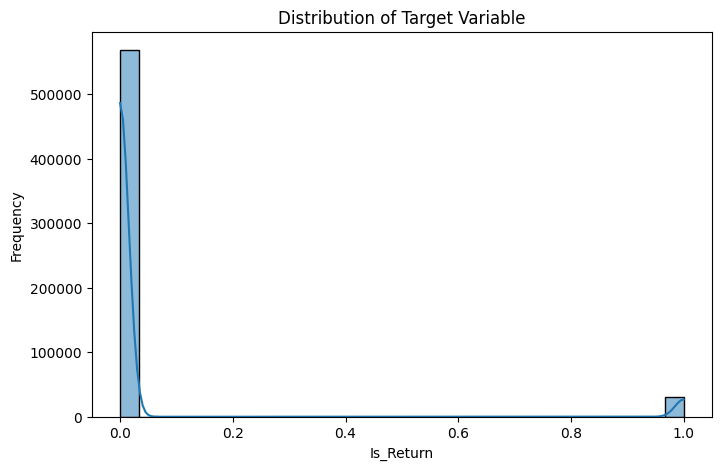

In [21]:
# ----- Target Distribution -----
plt.figure(figsize=(8,5))
sns.histplot(df[TARGET], kde=True, bins=30)
plt.title("Distribution of Target Variable")
plt.xlabel(TARGET)
plt.ylabel("Frequency")
plt.show()

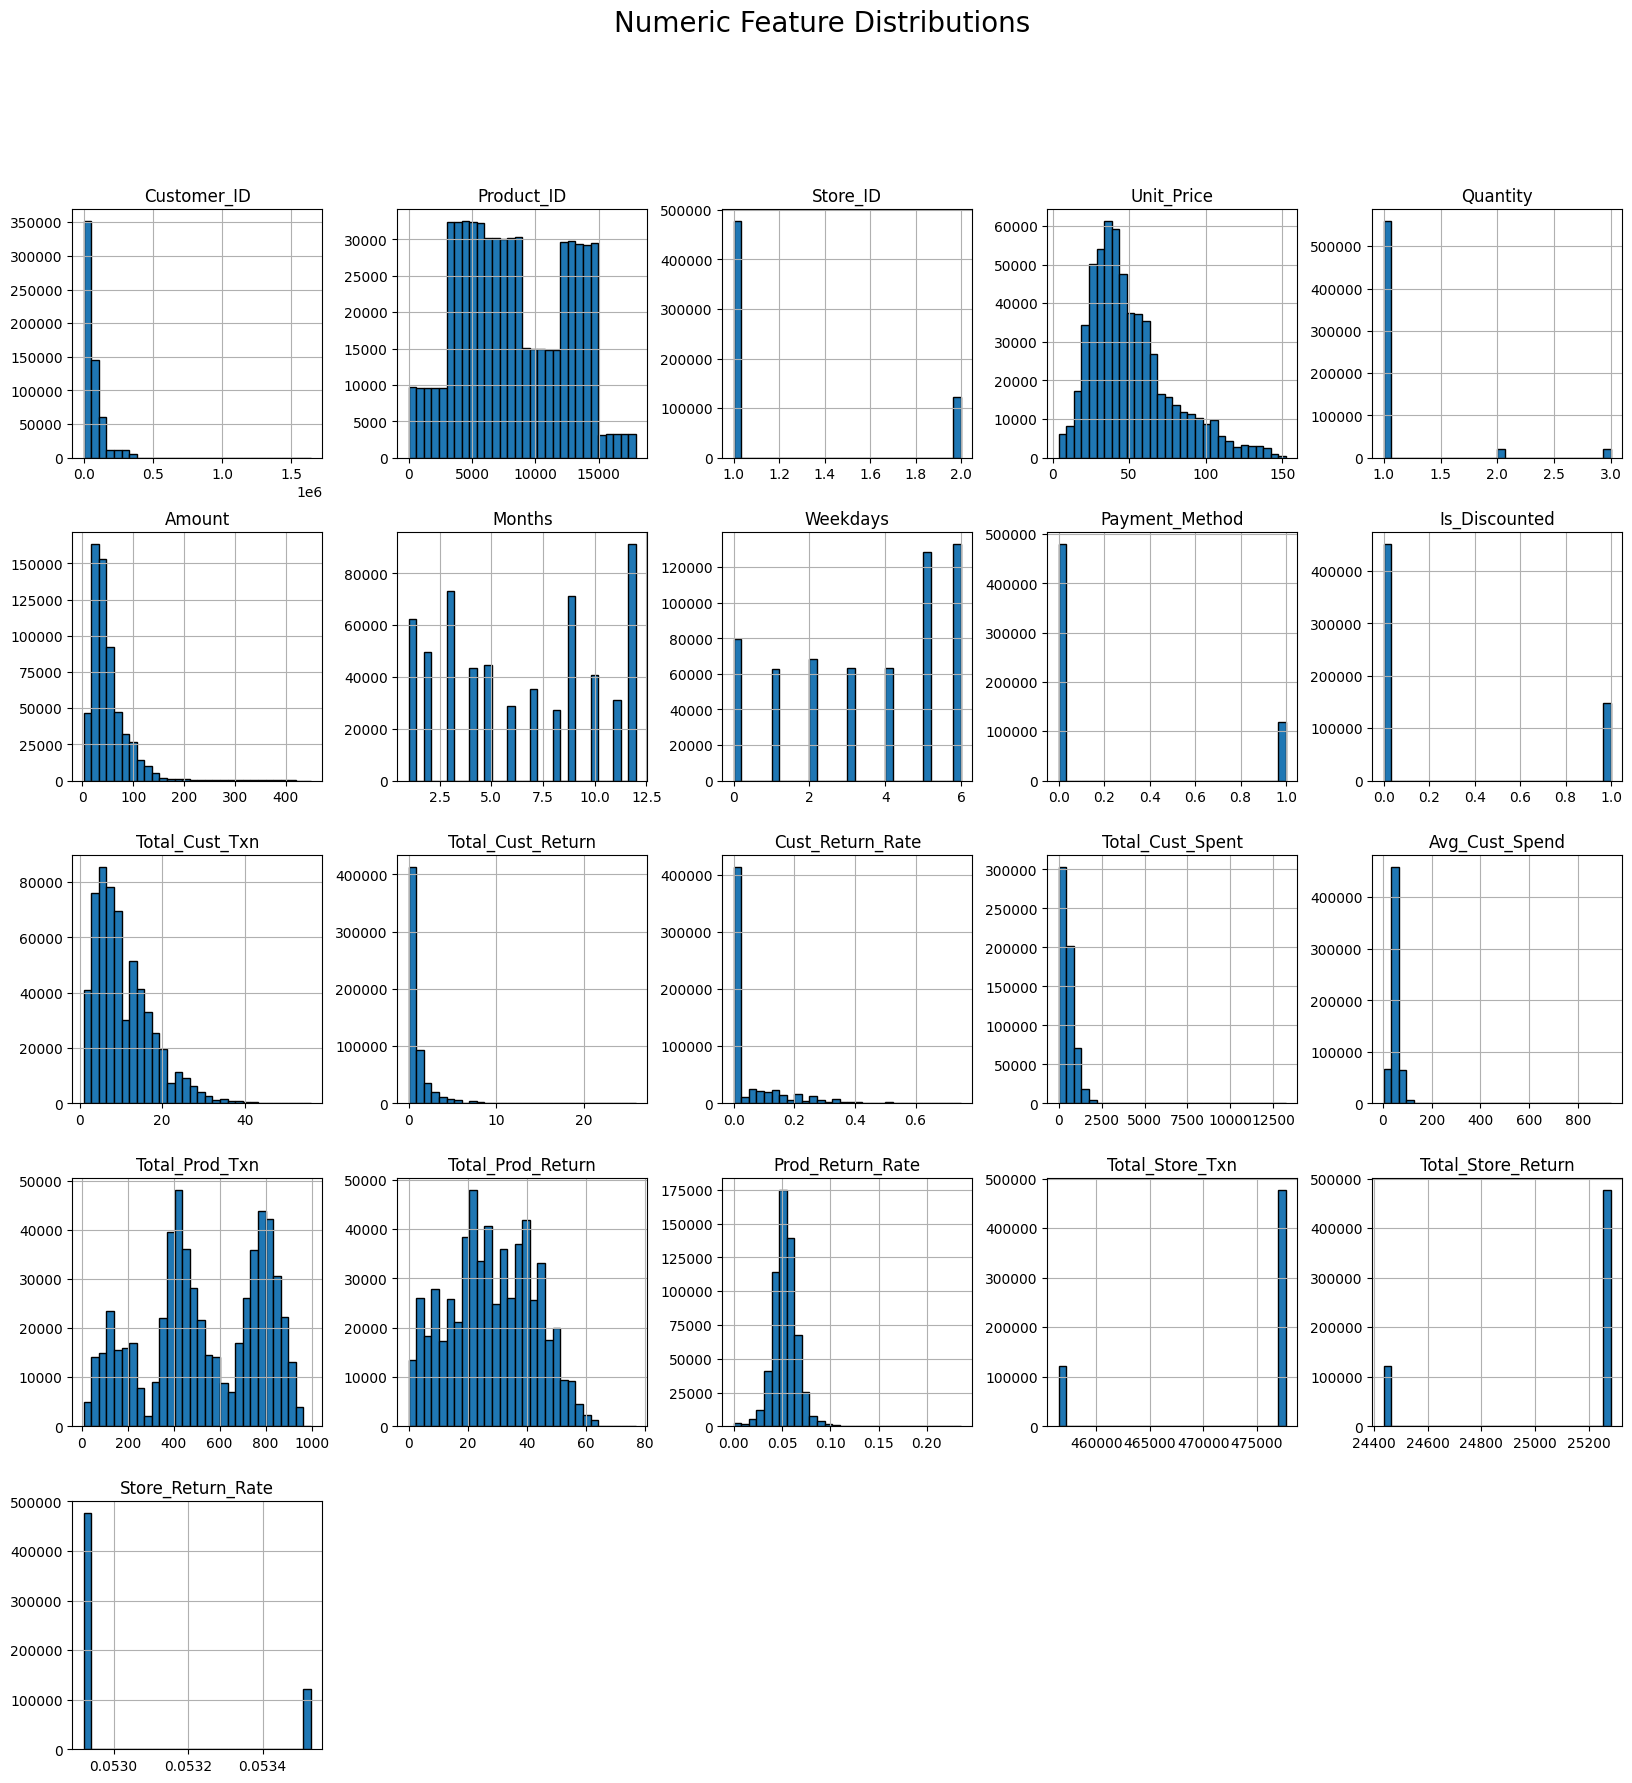

In [22]:
# ----- Numeric Feature Distributions -----
df[numeric_features].hist(figsize=(20, 20), bins=30, edgecolor='black')
plt.suptitle("Numeric Feature Distributions", fontsize=20)
plt.show()

In [24]:
# Define low-cardinality categorical columns
low_cardinality = [col for col in categorical_features if df[col].nunique() <= 20]

low_cardinality


['Currency']

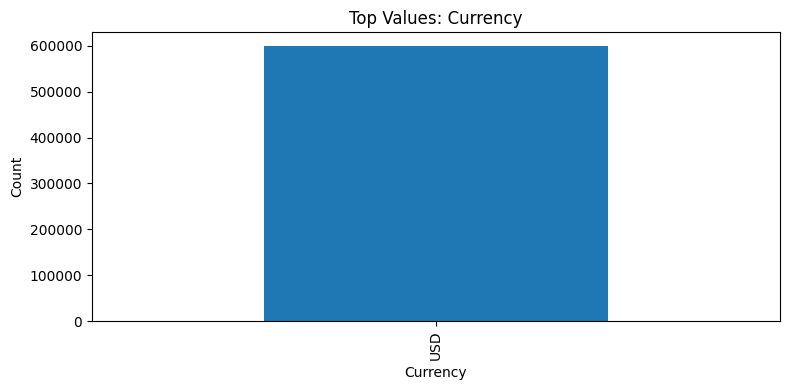

In [25]:
# ----- Categorical (Top Values Only) -----
for col in low_cardinality:
    plt.figure(figsize=(8,4))
    df[col].value_counts().head(20).plot(kind='bar')
    plt.title(f"Top Values: {col}")
    plt.xlabel(col)
    plt.ylabel("Count")
    plt.tight_layout()
    plt.show()


# Train/Test Split

In [40]:
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
    ]
)


In [41]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Logistic Regression Model

Logistic Regression Classification Report:
              precision    recall  f1-score   support

           0       0.96      0.99      0.98    113625
           1       0.62      0.26      0.37      6249

    accuracy                           0.95    119874
   macro avg       0.79      0.63      0.67    119874
weighted avg       0.94      0.95      0.94    119874

ROC-AUC Score: 0.9401548097200504


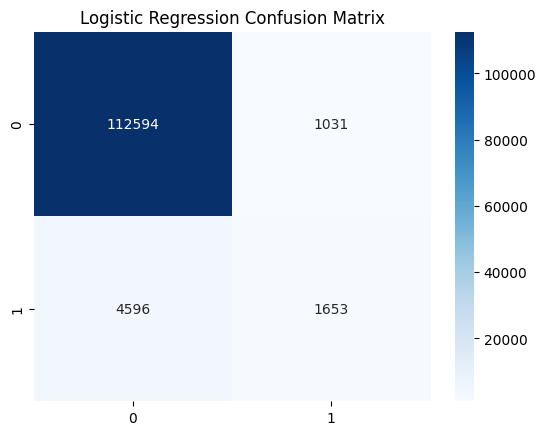

In [42]:
log_reg_model = Pipeline([
    ('preprocess', preprocessor),
    ('model', LogisticRegression(max_iter=1000))
])

log_reg_model.fit(X_train, y_train)

y_pred_lr = log_reg_model.predict(X_test)

print("Logistic Regression Classification Report:")
print(classification_report(y_test, y_pred_lr))

print("ROC-AUC Score:", roc_auc_score(y_test, log_reg_model.predict_proba(X_test)[:,1]))

cm_lr = confusion_matrix(y_test, y_pred_lr)
sns.heatmap(cm_lr, annot=True, fmt='d', cmap="Blues")
plt.title("Logistic Regression Confusion Matrix")
plt.show()

In [50]:
# example to test model
test_example = pd.DataFrame([{
    "Customer_ID": 12345,
    "Product_ID": 567,
    "Store_ID": 12,
    "Unit_Price": 15.99,
    "Quantity": 2,
    "Amount": 31.98,
    "Months": 5,
    "Weekdays": 3,
    "Payment_Method": 1,
    "Is_Discounted": 0,
    "Total_Cust_Txn": 85,
    "Total_Cust_Return": 3,
    "Cust_Return_Rate": 0.035,
    "Total_Cust_Spent": 900,
    "Avg_Cust_Spend": 45,
    "Total_Prod_Txn": 300,
    "Total_Prod_Return": 8,
    "Prod_Return_Rate": 0.026,
    "Total_Store_Txn": 500,
    "Total_Store_Return": 20,
    "Store_Return_Rate": 0.04,
    "Currency": "USD"     # categorical
}])

test_example


,Customer_ID,Product_ID,Store_ID,Unit_Price,Quantity,Amount,Months,Weekdays,Payment_Method,Is_Discounted,...,Cust_Return_Rate,Total_Cust_Spent,Avg_Cust_Spend,Total_Prod_Txn,Total_Prod_Return,Prod_Return_Rate,Total_Store_Txn,Total_Store_Return,Store_Return_Rate,Currency
0,12345,567,12,15.99,2,31.98,5,3,1,0,...,0.035,900,45,300,8,0.026,500,20,0.04,USD


In [51]:
# Predict probability of return
prob = log_reg_model.predict_proba(test_example)[:, 1][0]
print("Probability of Return:", prob)

# Predict class (0 = No Return, 1 = Return)
pred_class = log_reg_model.predict(test_example)[0]
print("Predicted Class:", pred_class)


Probability of Return: 0.9272727266775648
Predicted Class: 1


# Conclusion of Logistic Regression Model

Based on the model’s prediction, this transaction has a high estimated probability of being returned (92.7%). Since this probability exceeds the classification threshold used by the logistic regression model, the transaction is classified as likely to result in a return (Class = 1).

This indicates that the characteristics of this transaction—such as customer history, product return rate, discount status, payment method, and other behavioral or transactional features—align closely with patterns typically associated with returned items in the training data.

In practical terms, this prediction suggests that:
- The customer may be at high risk of returning the purchased item.

- The transaction may warrant closer review, additional communication, or return-prevention strategies (e.g., quality check, post-purchase engagement, or delivery confirmation).

- The model is functioning as expected, identifying transactions with a strong likelihood of return.

Overall, this prediction supports proactive decision-making to help the business reduce return-related losses or operational impact.

# Random Forest Model

Random Forest Classification Report:
              precision    recall  f1-score   support

           0       0.96      0.98      0.97    113625
           1       0.33      0.22      0.26      6249

    accuracy                           0.94    119874
   macro avg       0.64      0.60      0.61    119874
weighted avg       0.93      0.94      0.93    119874

ROC-AUC Score: 0.9216232631104366


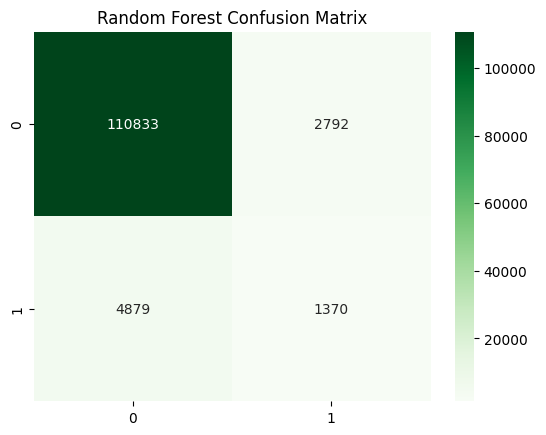

In [52]:
rf_model = Pipeline([
    ('preprocess', preprocessor),
    ('model', RandomForestClassifier(
        n_estimators=200,
        random_state=42
    ))
])

rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)

print("Random Forest Classification Report:")
print(classification_report(y_test, y_pred_rf))

print("ROC-AUC Score:", roc_auc_score(y_test, rf_model.predict_proba(X_test)[:,1]))

cm_rf = confusion_matrix(y_test, y_pred_rf)
sns.heatmap(cm_rf, annot=True, fmt='d', cmap="Greens")
plt.title("Random Forest Confusion Matrix")
plt.show()

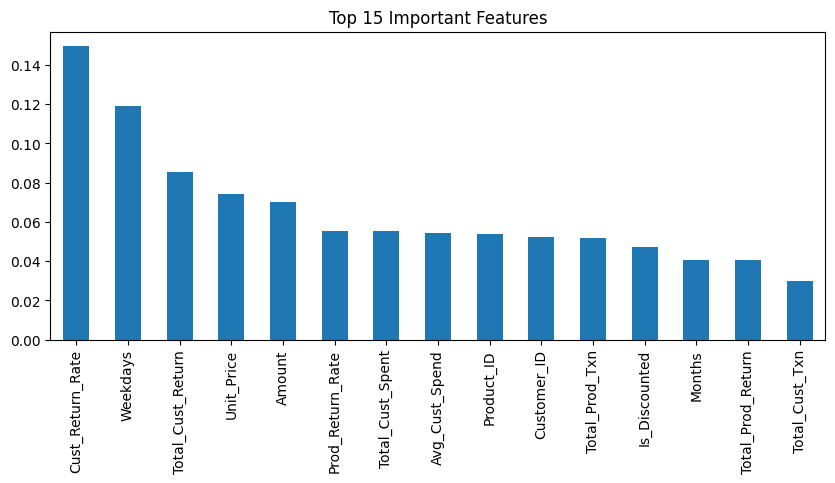

In [56]:
rf = rf_model.named_steps['model']
ohe = rf_model.named_steps['preprocess'].named_transformers_['cat']
ohe_features = ohe.get_feature_names_out(categorical_features)
all_features = numeric_features + list(ohe_features)

importances = pd.Series(rf.feature_importances_, index=all_features)
importances.sort_values(ascending=False).head(15).plot(kind='bar', figsize=(10,4))
plt.title("Top 15 Important Features")
plt.show()

In [57]:
# Example to test model
test_example_rf = pd.DataFrame([{
    "Customer_ID": 98765,
    "Product_ID": 432,
    "Store_ID": 15,
    "Unit_Price": 29.99,
    "Quantity": 1,
    "Amount": 29.99,
    "Months": 7,
    "Weekdays": 2,
    "Payment_Method": 1,
    "Is_Discounted": 1,
    "Total_Cust_Txn": 120,
    "Total_Cust_Return": 5,
    "Cust_Return_Rate": 0.0417,
    "Total_Cust_Spent": 1500,
    "Avg_Cust_Spend": 12.5,
    "Total_Prod_Txn": 250,
    "Total_Prod_Return": 10,
    "Prod_Return_Rate": 0.04,
    "Total_Store_Txn": 450,
    "Total_Store_Return": 15,
    "Store_Return_Rate": 0.033,
    "Currency": "USD"
}])

In [58]:
# Probability of return
prob_return = rf_model.predict_proba(test_example_rf)[:, 1][0]
print("Probability of Return:", prob_return)

# Predicted class (0 = No Return, 1 = Return)
pred_class = rf_model.predict(test_example_rf)[0]
print("Predicted Class:", pred_class)


Probability of Return: 0.01
Predicted Class: 0


# Conclusion of Random Forest Model

The model estimates a very low likelihood of this transaction being returned. Since the probability is well below the classification threshold (typically 0.5), the model predicts that the transaction will not result in a return.

This suggests that, based on the transaction’s characteristics—such as customer history, product metrics, store performance, payment method, discount status, and other features—this purchase aligns with patterns historically associated with non-returned transactions.

Business Implication

- The transaction is considered low risk for return.

- No immediate action is needed to prevent a return.

- Resources can instead be focused on monitoring transactions with higher predicted probabilities of return.

**2. Monthly Demand Forecasting**

**Goal:** Forecast monthly units sold by category and region

**Models:** SARIMA, ETS, or Gradient Boosting models

**Evaluation:** MAPE, RMSE against baseline models

# Data Load and Preprocessing

In [7]:
# Load and Inspect Data
from statsmodels.tools.sm_exceptions import ConvergenceWarning
warnings.simplefilter('ignore', ConvergenceWarning)

df = pd.read_csv("Monthly Demand Forecasting.csv")  # Update path

# Clean Month column
df['Months'] = df['Months'].astype(str).str.strip()
df['Month'] = pd.to_datetime(df['Months'], errors='coerce')
df = df.dropna(subset=['Month'])

# Aggregate total units sold per Month + Category + Country
df_agg = df.groupby(['Month','Category','Country'])['Total_Units_Sold'].sum().reset_index()

# Sort by Month
df_agg = df_agg.sort_values('Month').reset_index(drop=True)

# Encode Month numerically for Gradient Boosting
df_agg['Month_num'] = df_agg['Month'].dt.year*12 + df_agg['Month'].dt.month

df.head()

,Category,Country,Months,Total_Units_Sold,Total_Sales,Avg_Unit_Price,Avg_Effective_Price,Avg_Discount,Total_Discounted_Transactions,Total_Transactions,Month
0,Children,Deutschland,2023-01-01,3262,74740.420,29.241,22.942,0.189,1407,2978,2023-01-01
1,Children,Deutschland,2023-02-01,1525,38311.150,25.400,25.400,0.000,0,1355,2023-02-01
2,Children,Deutschland,2023-03-01,5606,179670.151,41.382,32.182,0.201,2915,5088,2023-03-01
3,Children,Deutschland,2023-04-01,2649,98858.500,37.227,37.227,0.000,0,2403,2023-04-01
4,Children,Deutschland,2023-05-01,4800,139982.875,33.831,29.224,0.148,2570,4334,2023-05-01


# SARIMA Forecast

In [8]:
##SARIMA Forecast (per Category & Country)
sarima_preds = []

for cat in df_agg['Category'].unique():
    for country in df_agg['Country'].unique():
        ts = df_agg[(df_agg['Category']==cat) & (df_agg['Country']==country)]
        ts = ts.set_index('Month').asfreq('MS')['Total_Units_Sold']

        # Skip if not enough data
        if ts.shape[0] < 12:
            continue

        # Train/Test split: last 6 months as test
        split_date = ts.index.max() - pd.DateOffset(months=6)
        ts_train = ts[ts.index <= split_date]
        ts_test = ts[ts.index > split_date]

        # Fit SARIMA
        model = SARIMAX(ts_train, order=(1,1,1), seasonal_order=(1,1,1,12),
                        enforce_stationarity=False, enforce_invertibility=False)
        model_fit = model.fit(disp=False)

        # Forecast
        forecast = model_fit.get_forecast(len(ts_test))
        pred_mean = forecast.predicted_mean

        sarima_preds.append(pd.DataFrame({
            'Month': ts_test.index,
            'Category': cat,
            'Country': country,
            'SARIMA_Pred': pred_mean.values,
            'Actual': ts_test.values
        }))

sarima_df = pd.concat(sarima_preds).reset_index(drop=True)
sarima_df.head()


,Month,Category,Country,SARIMA_Pred,Actual
0,2024-10-01,Children,Deutschland,6355.958346,5069
1,2024-11-01,Children,Deutschland,3968.079239,2733
2,2024-12-01,Children,Deutschland,10075.269368,10120
3,2025-01-01,Children,Deutschland,4343.717568,3301
4,2025-02-01,Children,Deutschland,3085.671355,1482


## Data Fixing for GradientBoosting

In [166]:
# Sort by Category, Country, Month
df_agg = df_agg.sort_values(['Category','Country','Month'])

# Lag features
df_agg['Lag1'] = df_agg.groupby(['Category','Country'])['Total_Units_Sold'].shift(1)
df_agg['Lag2'] = df_agg.groupby(['Category','Country'])['Total_Units_Sold'].shift(2)

# Rolling averages
df_agg['Rolling3'] = df_agg.groupby(['Category','Country'])['Total_Units_Sold'].shift(1).rolling(3).mean()
df_agg['Rolling6'] = df_agg.groupby(['Category','Country'])['Total_Units_Sold'].shift(1).rolling(6).mean()
df_agg['Rolling12'] = df_agg.groupby(['Category','Country'])['Total_Units_Sold'].shift(1).rolling(12).mean()

# Fill NaNs for initial months
df_agg[['Lag1','Lag2','Rolling3','Rolling6','Rolling12']] = df_agg[['Lag1','Lag2','Rolling3','Rolling6','Rolling12']].fillna(0)

# Normalized Month_num
month_min = df_agg['Month_num'].min()
month_max = df_agg['Month_num'].max()
df_agg['Month_num_norm'] = (df_agg['Month_num'] - month_min) / (month_max - month_min)

# Month-of-year feature for seasonality
df_agg['Month_of_year'] = df_agg['Month'].dt.month.astype(str)

## Train Test Split

In [167]:
#Train Test Split
split_date = df_agg['Month'].max() - pd.DateOffset(months=6)
df_train = df_agg[df_agg['Month'] <= split_date].copy()
df_test = df_agg[df_agg['Month'] > split_date].copy()

feature_cols = ['Category','Country','Month_num_norm','Lag1','Lag2','Rolling3','Rolling6','Rolling12','Month_of_year']
X_train = df_train[feature_cols]
y_train = df_train['Total_Units_Sold']
X_test = df_test[feature_cols]
y_test = df_test['Total_Units_Sold']

# Log-transform target to stabilize variance
y_train_log = np.log1p(y_train)

# GradientBoosting Forecasting

In [168]:
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import GradientBoostingRegressor

# Preprocessor: categorical + numeric
preprocessor = ColumnTransformer(transformers=[
    ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), ['Category','Country','Month_of_year']),
    ('num', 'passthrough', ['Month_num_norm','Lag1','Lag2','Rolling3','Rolling6','Rolling12'])
])

# Gradient Boosting Regressor with tuned hyperparameters
gbr_model = Pipeline([
    ('preprocess', preprocessor),
    ('model', GradientBoostingRegressor(
        n_estimators=500,
        learning_rate=0.05,
        max_depth=4,
        min_samples_split=5,
        min_samples_leaf=3,
        random_state=42
    ))
])

# Train
gbr_model.fit(X_train, y_train_log)

# Predict and invert log-transform
df_test['GBR_Pred'] = np.expm1(gbr_model.predict(X_test))

# Check results
df_test[['Month','Category','Country','Total_Units_Sold','GBR_Pred']].head(10)


,Month,Category,Country,Total_Units_Sold,GBR_Pred
453,2024-10-01,Children,Deutschland,5069,4594.045115
481,2024-11-01,Children,Deutschland,2733,2696.485347
495,2024-12-01,Children,Deutschland,10120,9644.567743
520,2025-01-01,Children,Deutschland,3301,3843.650028
544,2025-02-01,Children,Deutschland,1482,1975.053893
563,2025-03-01,Children,Deutschland,2453,7401.838494
454,2024-10-01,Children,España,4482,3736.715195
480,2024-11-01,Children,España,2157,2208.967774
496,2024-12-01,Children,España,7653,7403.540387
516,2025-01-01,Children,España,2282,2439.331450


# SARIMA vs Gradient Boosting predictions

In [169]:
# Merge SARIMA predictions with Gradient Boosting predictions
comparison_df = sarima_df.merge(
    df_test[['Month','Category','Country','GBR_Pred']],
    on=['Month','Category','Country'], how='left'
)
comparison_df.head()

,Month,Category,Country,SARIMA_Pred,Actual,GBR_Pred
0,2024-10-01,Children,Deutschland,6355.958346,5069,4594.045115
1,2024-11-01,Children,Deutschland,3968.079239,2733,2696.485347
2,2024-12-01,Children,Deutschland,10075.269368,10120,9644.567743
3,2025-01-01,Children,Deutschland,4343.717568,3301,3843.650028
4,2025-02-01,Children,Deutschland,3085.671355,1482,1975.053893


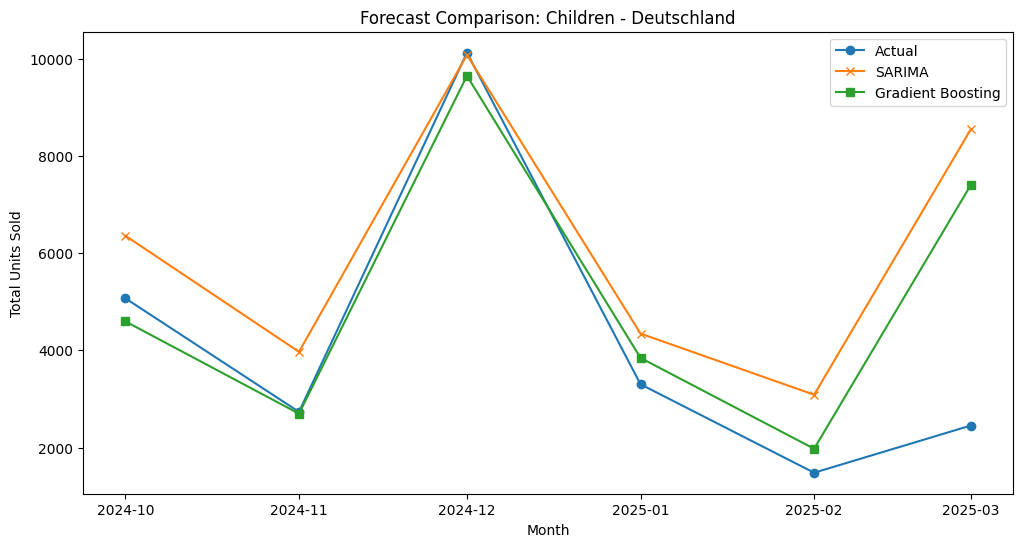

In [170]:
# Example plot: Children - Deutschland
example = comparison_df[(comparison_df['Category']=='Children') & 
                        (comparison_df['Country']=='Deutschland')]

plt.figure(figsize=(12,6))
plt.plot(example['Month'], example['Actual'], label='Actual', marker='o')
plt.plot(example['Month'], example['SARIMA_Pred'], label='SARIMA', marker='x')
plt.plot(example['Month'], example['GBR_Pred'], label='Gradient Boosting', marker='s')
plt.title('Forecast Comparison: Children - Deutschland')
plt.xlabel('Month')
plt.ylabel('Total Units Sold')
plt.legend()
plt.show()

## MAPE And RMSE Comparision

In [171]:
from sklearn.metrics import mean_absolute_percentage_error, mean_squared_error
import numpy as np

# SARIMA metrics
sarima_mape = mean_absolute_percentage_error(comparison_df['Actual'], comparison_df['SARIMA_Pred'])
sarima_rmse = np.sqrt(mean_squared_error(comparison_df['Actual'], comparison_df['SARIMA_Pred']))

# Gradient Boosting metrics
gbr_mape = mean_absolute_percentage_error(comparison_df['Actual'], comparison_df['GBR_Pred'])
gbr_rmse = np.sqrt(mean_squared_error(comparison_df['Actual'], comparison_df['GBR_Pred']))

print(f"SARIMA: MAPE={sarima_mape:.4f}, RMSE={sarima_rmse:.2f}")
print(f"Gradient Boosting: MAPE={gbr_mape:.4f}, RMSE={gbr_rmse:.2f}")



SARIMA: MAPE=0.5853, RMSE=6730.45
Gradient Boosting: MAPE=0.3834, RMSE=5421.11


## Future Forecasting using SARIMA

In [13]:
final_model = SARIMAX(ts, order=(1,1,1), seasonal_order=(1,1,1,6)).fit()

future_forecast = final_model.forecast(12)
future_forecast

2025-04-01    11412.023392
2025-05-01    10799.872796
2025-06-01    10569.346930
2025-07-01     5963.186721
2025-08-01     6378.419456
2025-09-01    15478.155254
2025-10-01    14320.312120
2025-11-01    10732.283415
2025-12-01    40328.464577
2026-01-01     6697.438446
2026-02-01     4672.179923
2026-03-01     5780.609100
Freq: MS, Name: predicted_mean, dtype: float64

## Future Forecasting using Gradient Boosting

In [181]:
def make_features(df):
    df = df.sort_values("Month")

    df["Lag1"] = df["Total_Units_Sold"].shift(1)
    df["Lag2"] = df["Total_Units_Sold"].shift(2)

    df["Rolling3"] = df["Total_Units_Sold"].shift(1).rolling(3).mean()
    df["Rolling6"] = df["Total_Units_Sold"].shift(1).rolling(6).mean()
    df["Rolling12"] = df["Total_Units_Sold"].shift(1).rolling(12).mean()

    df[["Lag1","Lag2","Rolling3","Rolling6","Rolling12"]] = \
        df[["Lag1","Lag2","Rolling3","Rolling6","Rolling12"]].fillna(0)

    df["Month_num"] = (df["Month"].dt.year - df["Month"].dt.year.min())*12 + df["Month"].dt.month

    # Normalize Month_num (must match training!)
    df["Month_num_norm"] = (df["Month_num"] - df["Month_num"].min()) / (df["Month_num"].max() - df["Month_num"].min())

    df["Month_of_year"] = df["Month"].dt.month.astype(str)

    return df


In [186]:
def gbr_forecast(df, model, periods=12):
    df_fc = df.copy().sort_values("Month")

    for _ in range(periods):
        next_month = df_fc["Month"].max() + pd.DateOffset(months=1)

        # add blank row with matching columns
        new_row = pd.DataFrame({
            "Month": [next_month],
            "Category": [df_fc["Category"].iloc[0]],
            "Country": [df_fc["Country"].iloc[0]],
            "Total_Units_Sold": [None]
        })

        df_fc = pd.concat([df_fc, new_row], ignore_index=True)

        # rebuild all features
        df_fc = make_features(df_fc)

        # select the row to predict
        row = df_fc[df_fc["Month"] == next_month]

        feature_cols = [
            "Category","Country","Month_num_norm",
            "Lag1","Lag2","Rolling3","Rolling6","Rolling12",
            "Month_of_year"
        ]

        X = row[feature_cols]

        pred = np.expm1(model.predict(X)[0])

        df_fc.loc[df_fc["Month"] == next_month, "Total_Units_Sold"] = pred

    return df_fc.tail(periods)[["Month","Total_Units_Sold"]]


In [187]:
df_subset = df_agg[
    (df_agg["Category"]=="Children") &
    (df_agg["Country"]=="Deutschland")
].copy()

future = gbr_forecast(df_subset, gbr_model, periods=12)
future


,Month,Total_Units_Sold
27,2025-04-01,2655.649093
28,2025-05-01,4215.315735
29,2025-06-01,1895.686391
30,2025-07-01,2000.975753
31,2025-08-01,2338.531751
32,2025-09-01,6450.682196
33,2025-10-01,4572.528004
34,2025-11-01,2595.666999
35,2025-12-01,9617.192227
36,2026-01-01,3147.096716


# Conclusion

**Interpretation**

**Accuracy**

- Gradient Boosting outperforms SARIMA
    - ~34% lower error in MAPE
    - ~20% lower error in RMSE

**Reason**

- GBR uses lagged sales + rolling averages + trend features, allowing it to capture local patterns even with volatile sales.

- SARIMA struggles because retail demand is:

    - non-stationary

    - highly variable

    - influenced by category/country effects

As a result, SARIMA’s predictions fluctuate more wildly and deviate more from actual values.

**Gradient Boosting is the better forecasting model for this series.
It provides more stable predictions, lower error, and better alignment with actual sales**